
<p style="font-size:50px">
<span style="font-size:200px">
&#9703;
</span>
Broadcasting et vectorisation
</p>

---



Sous-sections :
[Broadcasting](#broadcasting)&nbsp;|
[Vectorisation](#vectorisation)&nbsp;|
[Exercices](#exercices)&nbsp;


NumPy tire partie de sa stratégie de stockage des tableaux
dans des blocs mémoire contigüs de taille fixe pour optimiser les
traitements.

<a id="broadcasting"></a>
##### Broadcasting

NumPy peut faire des opérations sur des tableaux qui n'ont pas la même géométrie (*shape*), comme ici :
![broadcast example](../images/broadcasting_1.png)

In [12]:
import numpy as np

a = np.array([1, 2, 3])  # shape (3,)
b = np.array([2])  # shape (1,)

In [13]:
a * b  # ou simplement a * 2, on multiplie par 2 à chaque élément du tableau a

array([2, 4, 6])

On peut utiliser cette technique par exemple 
pour calculer les différences entre une nouvelle entrée __x__ et chacune des entrées __xi__ de la base de cas :

In [14]:
import numpy as np
X = np.array(
    [
        (2, -5),
        (8, -4),
        (-17, -23),
        (28, 0),
        (-8, -7),
        (3, 2.9),
        (23, 14),
        (7, 14),
        (-2, 28),
    ]
)
x = np.array((0, 3))

x - X

array([[ -2. ,   8. ],
       [ -8. ,   7. ],
       [ 17. ,  26. ],
       [-28. ,   3. ],
       [  8. ,  10. ],
       [ -3. ,   0.1],
       [-23. , -11. ],
       [ -7. , -11. ],
       [  2. , -25. ]])

Pour que cette technique de [broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html) puisse être appliquée, NumPy impose que dans chaque dimension, les deux tableaux contiennent :
- soit le même nombre d'élément
- soit 1 seul élément

NumPy fabrique alors des tableaux de même géométrie en dupliquant les valeurs lorsqu'une dimension ne contient qu'un élément,
puis, une fois qu'il a des tableaux de même géométrie,
applique l'opération sur les éléments 2 à 2.

Par exemple, on peut multiplier (opération `*`) un tableau de géométrie (1,3) avec un tableau de géométrie (2,1), et le résultat sera un tableau de géométrie (2,3).



In [15]:
a = np.array([1, 2, 3])  # shape (3,)
b = np.array([[3], [7]])  # shape (2,1)
a * b

array([[ 3,  6,  9],
       [ 7, 14, 21]])

car les tableaux `a` et `b` sont étendus de la manière suivante :

In [16]:
a = np.array([1, 2, 3])  # shape (3,)
a = np.array([[1, 2, 3]])  # -> extended to shape (1,3)
a = np.array([[1, 2, 3], [1, 2, 3]])  # -> extended to shape (2,3)

b = np.array([[3], [7]])  # shape (2,1)
b = np.array([[3, 3, 3], [7, 7, 7]])  # -> extended to shape (2,3)

a * b

array([[ 3,  6,  9],
       [ 7, 14, 21]])

<a id="vectorisation"></a>
##### Vectorisation

NumPy est également très efficace pour appliquer une même fonction sur tous les éléments d'un tableau. Le processus qui permet de rendre ce comportement possible est appelé 
__vectorisation__ de la fonction.

Par exemple, on peut calculer d'un seul coup les carrés des distances euclidiennes pour tous les couples (__x__,__xi__) :

In [17]:
np.linalg.norm(x-X,axis=1)

array([ 8.24621125, 10.63014581, 31.06444913, 28.16025568, 12.80624847,
        3.0016662 , 25.49509757, 13.03840481, 25.07987241])

Il sera bien plus efficace (en temps de calcul) d'appliquer une fonction (vectorisée) à tous les éléments du tableau que de faire une boucle `for`, comme le montre l'exemple ci-dessous :

<Axes: xlabel='x', ylabel='y'>

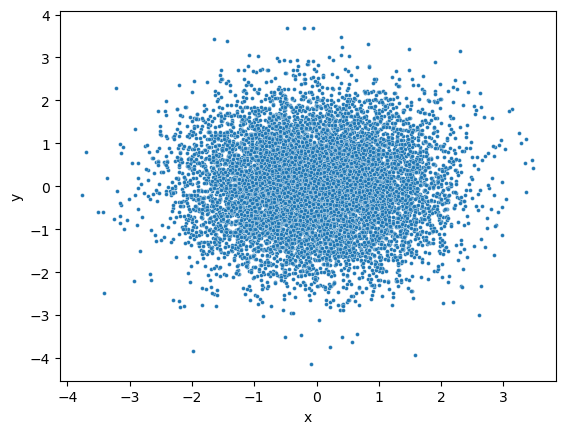

In [18]:
N = 10000
X_random = np.random.default_rng().normal(size=(N,2))
import seaborn as sns
import pandas as pd
df = pd.DataFrame(data=X_random, columns=['x','y'])
sns.scatterplot(data=df, x='x', y='y', s=8)

In [19]:
%%timeit
# avec une boucle for
norms = []
for x in X_random:
    norms.append(np.linalg.norm(x))

34.5 ms ± 4.86 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [20]:
# avec vectorisation
%timeit np.linalg.norm(X_random,axis=1)

198 μs ± 18.5 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


--- 

<a id="exercices"></a>
##### Exercices

Réécrire la fonction `euclidean_sim` avec NumPy pour tirer partie du broadcasting et des fonctions vectorisées `np.linalg.norm` et `np.exp`.

On fera en sorte que l'un ou l'autre des arguments `a` et `b` de la fonction puisse être un tableau de dimension $2$ (p.ex., lorsque `a.ndim == 2`).

In [ ]:
def euclidean_sim(a,b):
    pass
    # completer ici
   

# --------- tests -------- #
try:
    similarites = euclidean_sim(x,X)
    assert similarites[1] == 2.417610491679649e-05, f'Erreur : la deuxième similarité trouvée doit être 2.417610491679649e-05, et non {similarites[1]}.'
    assert euclidean_sim(x,x) == 1., 'Erreur : la similarité entre x et lui-même doit valoir 1.'
    similarite = euclidean_sim(x,x+1)
    assert similarite == 0.2431167344342142, 'Erreur : la similarite entre x et x+1 doit être 0.2431167344342142.'
    print('ok')
except AssertionError as e:
    print(e)   

similarites


Réécrire la fonction `cosin()` avec NumPy.

Une stratégie pourra consister à successivement à :
- diviser les vecteurs `a` et `b` par leur norme (selon l'axe 1)
- multiplier 2 à 2 les éléments des vecteurs unitaires obtenus `a_unit` et `b_unit`
- finalement, faire la somme des éléments du vecteur produit 


In [ ]:
def cosin(a,b):
    if len(a.shape) == 1:
        a = np.expand_dims(a,0)
    if len(b.shape) == 1:
        b = np.expand_dims(b,0)
    ...
    # completer ici
    # a_unit = ...
    # b_unit = ...
       
    return np.sum(a_unit*b_unit, axis=1)

# --------- tests -------- #
try:
    similarites = cosin(x,X)
    assert similarites[1] == -0.4472135954999579, f'Erreur : la deuxième similarité trouvée doit être -0.4472135954999579, et non {similarites[1]}.'
    assert cosin(x,x) == 1, 'Erreur : la similarité entre x et lui-même doit valoir 1.'
    assert np.isclose(cosin(x,x+1), 0.9701425), 'Erreur : la similarite entre x et x+1 doit être 0.9701425.'
    print('ok')
except AssertionError as e:
    print(e)   


Proposer une nouvelle implémentation du module `cbp.similarity.measures` qui utilise NumPy.

In [ ]:
from cbp.similarity.measures import cosin

cosin(x,X)